In [1]:
import sys
import os

In [2]:
# from helpers.dataframeBuilder import get_df_neigbours_answer_for_all_itemIDs
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../csv/preprocessed_data.csv')

In [4]:
df.set_index(['TestKey'])

,CandidateKey,Q0_A1,Q0_A2,Q0_A3,Q0_A4,Q0_A5,Q0_A6,Q1_A1,Q1_A2,Q1_A3,...,Q2_A3,Q2_A4,Q2_A5,Q2_A6,Q3_A1,Q3_A2,Q3_A3,Q3_A4,Q3_A5,Q3_A6
TestKey,,,,,,,,,,,,,,,,,,,,,
251025,5640161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
251170,5021111,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,...,0.0,6.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
251171,5033381,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
251172,5104761,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.0,...,0.0,6.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0
251173,5034311,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501604,45644175,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,6.0,0.0,0.0,0.0,1.0,0.0,2.0,0.0,0.0
501605,45644745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,6.0,0.0,0.0,4.0,1.0,0.0,4.0,0.0,0.0
501606,45644805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,2.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0


In [5]:
X = df.select_dtypes(include=[np.number]).values

In [6]:
# Vervang NaN-waarden door de mediaan van elke kolom
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

In [7]:
X = X.astype(np.float64)

In [8]:
print(X.shape)

(249774, 26)


# Modellen trainen

In [9]:
# voor elke model dezelfde contamination
contamination= 0.05

In [10]:
def predict_model(model, df, name):
    df_answers=df
    
    model.fit(X)
    
    df_answers['anomaly_score'] = model.decision_scores_
    df_answers['is_anomaly'] = model.predict(X)

    df_answers = df_answers.reset_index()
    df_answers = df_answers[['TestKey','anomaly_score', 'is_anomaly']]
    
    print(f"Aantal gedetecteerde anomalieën: {df_answers['is_anomaly'].sum()}")

    df_answers.set_index('TestKey', inplace=True)
    df_answers.to_csv(f"../csv/{name}.csv")
    df_answers.reset_index(inplace=True)
    
    return df_answers

## ECOD

In [11]:
from pyod.models.ecod import ECOD

ecod = ECOD(contamination=contamination)

In [12]:
df_ecod = predict_model(ecod, df, "ecod")

Aantal gedetecteerde anomalieën: 12489


In [13]:
df_ecod[df_ecod['is_anomaly'] == 1].head()

,TestKey,anomaly_score,is_anomaly
0,251025,19.399244,1
1,251170,20.749032,1
2,251171,18.296514,1
3,251172,17.327609,1
4,251173,17.397684,1


## Isolation forest

In [14]:
from pyod.models.iforest import IForest

i_forest = IForest(contamination=contamination, n_estimators=100, max_samples='auto')

In [15]:
df_iForest = predict_model(i_forest, df, 'i_forest')

Aantal gedetecteerde anomalieën: 12489


## LOF

In [16]:
from pyod.models.lof import LOF

lof = LOF(contamination=contamination)

In [17]:
df_lof = predict_model(lof, df, 'lof')

Aantal gedetecteerde anomalieën: 11192


## COPOD 

In [18]:
from pyod.models.copod import COPOD

copod = COPOD(contamination=contamination, n_jobs=-1)

In [19]:
df_copod = predict_model(copod, df,'copod')

[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    9.3s remaining:  1.1min
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:   10.2s finished
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done   2 out of  16 | elapsed:    0.6s remaining:    4.8s
[Parallel(n_jobs=16)]: Done  16 out of  16 | elapsed:    1.2s finished


Aantal gedetecteerde anomalieën: 12489


## ABOD

In [20]:
from pyod.models.abod import ABOD

abod = ABOD(contamination=contamination, method='fast', n_neighbors=10)

In [21]:
df_abod = predict_model(abod, df, 'abod')

Aantal gedetecteerde anomalieën: 12090


In [22]:
df_abod[df_abod['is_anomaly'] == 1].head()

,TestKey,anomaly_score,is_anomaly
1,251170,-6.585741e-16,1
3,251172,-2.325156e-15,1
6,251254,-1.637894e-15,1
16,251303,-1.166360e-14,1
17,251304,-2.025031e-15,1


## Overeenkomsten

### functie voor analyse

In [23]:
df_copod

,TestKey,anomaly_score,is_anomaly
0,251025,17.972433,1
1,251170,19.912430,1
2,251171,17.240732,1
3,251172,16.459352,1
4,251173,15.957867,1
...,...,...,...
249769,501604,12.676756,1
249770,501605,12.699298,1
249771,501606,10.395246,0
249772,501607,9.763843,0


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn2

def compare_anomaly_models(*model_dfs, id_column='TestKey'):
    """
    Vergelijkt anomaliedetecties van meerdere modellen.
    
    :param model_dfs: Een lijst van tuples, elk met (dataframe, model_name)
    :param id_column: De naam van de kolom die als identifier wordt gebruikt
    :return: Een DataFrame met gecombineerde resultaten
    """
    # Initialiseer de gecombineerde DataFrame met de ID-kolom
    df_combined = pd.DataFrame({id_column: model_dfs[0][0][id_column]})
    
    # Voeg resultaten van elk model toe
    model_names = []
    for df, model_name in model_dfs:
        model_names.append(model_name)
        df_combined = df_combined.merge(
            df[[id_column, 'is_anomaly']],
            on=id_column,
            suffixes=('', f'_{model_name}')
        )
        df_combined = df_combined.rename(columns={'is_anomaly': f'{model_name}_anomaly'})
    
    # Tel het aantal anomaliedetecties per datapunt
    anomaly_columns = [col for col in df_combined.columns if col.endswith('_anomaly')]
    df_combined['anomaly_count'] = df_combined[anomaly_columns].sum(axis=1)
    
    # Analyseer de overeenkomsten
    print("Verdeling van anomaliedetecties:")
    print(df_combined['anomaly_count'].value_counts().sort_index())
    
    # # Visualiseer de overeenkomsten
    plt.figure(figsize=(10, 6))
    df_combined['anomaly_count'].value_counts().sort_index().plot(kind='bar')
    plt.title('Aantal datapunten gedetecteerd als anomalie door x modellen')
    plt.xlabel('Aantal modellen')
    plt.ylabel('Aantal datapunten')
    plt.show()
    
    # Bekijk consensus anomalieën
    consensus_anomalies = df_combined[df_combined['anomaly_count'] == len(model_dfs)]
    print(f"\nAantal datapunten gedetecteerd als anomalie door alle {len(model_dfs)} modellen:", 
          len(consensus_anomalies))
    # print("\nVoorbeelden van consensus anomalieën:")
    # print(consensus_anomalies.head())
    
    # Vergelijk modellen paarsgewijs
    print("\nPaarsgewijze vergelijking van modellen:")
    for i in range(len(model_names)):
        for j in range(i+1, len(model_names)):
            agreement = (df_combined[f'{model_names[i]}_anomaly'] == df_combined[f'{model_names[j]}_anomaly']).mean()
            print(f"Overeenkomst tussen {model_names[i].upper()} en {model_names[j].upper()}: {agreement:.2%}")
    
    # Visualiseer de overlap van anomalieën met een Venn diagram alleen als er 3 modellen zijn
    if len(model_names) == 3:
        plt.figure(figsize=(8, 7))
        venn3([set(df_combined[df_combined[f'{model}_anomaly'] == 1][id_column]) for model in model_names],
              set_labels=model_names)
        plt.title("Overlap van gedetecteerde anomalieën")
        plt.show()
    else:
        print("\nVenn diagram wordt alleen gemaakt voor exact 3 modellen.")
    
    return df_combined

### uitvoeren

Verdeling van anomaliedetecties:
anomaly_count
0    213124
1     20742
2      8753
3      6260
4       754
5       141
Name: count, dtype: int64


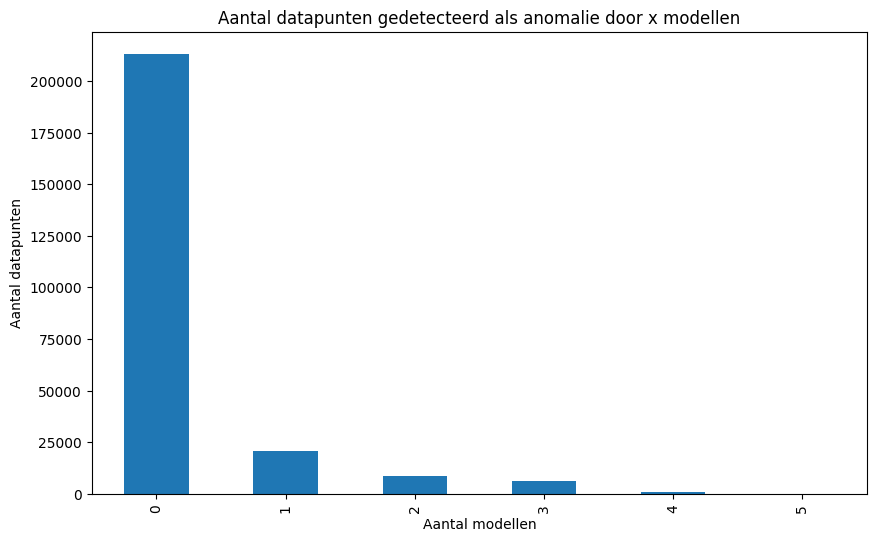


Aantal datapunten gedetecteerd als anomalie door alle 5 modellen: 141

Paarsgewijze vergelijking van modellen:
Overeenkomst tussen ECOD en I_FOREST: 95.94%
Overeenkomst tussen ECOD en LOF: 90.96%
Overeenkomst tussen ECOD en COPOD: 97.11%
Overeenkomst tussen ECOD en ABOD: 90.95%
Overeenkomst tussen I_FOREST en LOF: 91.01%
Overeenkomst tussen I_FOREST en COPOD: 96.07%
Overeenkomst tussen I_FOREST en ABOD: 90.91%
Overeenkomst tussen LOF en COPOD: 90.95%
Overeenkomst tussen LOF en ABOD: 94.25%
Overeenkomst tussen COPOD en ABOD: 91.35%

Venn diagram wordt alleen gemaakt voor exact 3 modellen.


In [25]:
df_combined = compare_anomaly_models(
    (df_ecod, 'ecod'),
    (df_iForest, 'i_forest'),
    (df_lof, 'lof'),
    (df_copod, 'copod'),
    (df_abod, 'abod'),
)

In [26]:
df_combined

,TestKey,ecod_anomaly,i_forest_anomaly,lof_anomaly,copod_anomaly,abod_anomaly,anomaly_count
0,251025,1,0,0,1,0,2
1,251170,1,1,0,1,1,4
2,251171,1,0,0,1,0,2
3,251172,1,0,0,1,1,3
4,251173,1,0,0,1,0,2
...,...,...,...,...,...,...,...
249769,501604,1,0,0,1,0,2
249770,501605,1,1,0,1,0,3
249771,501606,1,0,0,0,0,1
249772,501607,1,0,0,0,0,1


In [27]:
df_combined.to_csv('../csv/comparison.csv', index=False)

# SOUD

In [ ]:
# from pyod.models.suod import SUOD
# from pyod.models.lof import LOF
# from pyod.models.iforest import IForest
# from pyod.models.copod import COPOD
# from pyod.models.knn import KNN
# from pyod.models.hbos import HBOS

In [ ]:
# base_estimators = [
#     IForest(n_estimators=100, max_samples='auto', contamination=contamination, random_state=42),
#     # LOF(n_neighbors=20, contamination=contamination),
#     ECOD(contamination=contamination),
#     COPOD(contamination=contamination)
# ]

In [ ]:
# # Initialiseer SUOD
# suod = SUOD(base_estimators=base_estimators, 
#             n_jobs=2,  # aantal parallelle jobs
#             combination='average',  # methode om scores te combineren
#             verbose=False)

In [31]:
def data_generator(X, batch_size=1000):
    for i in range(0, len(X), batch_size):
        yield X[i:i + batch_size]

In [32]:
# Functie om SUOD te trainen en voorspellingen te maken met batches
def process_batches(X, batch_size=1000):
    anomaly_scores = []
    
    # Train SUOD op batches
    for batch in data_generator(X, batch_size):
        suod.fit(batch)  # Train op de huidige batch
        batch_scores = suod.decision_function(batch)  # Verkrijg anomalie scores voor de batch
        anomaly_scores.extend(batch_scores)  # Voeg scores toe aan de lijst
    
    return np.array(anomaly_scores)

In [ ]:
# # Verwerk de data in batches en verkrijg anomalie scores
# anomaly_scores = process_batches(X, batch_size=1000)

# # Bepaal anomalieën op basis van de scores (bijvoorbeeld top 5% als anomalieën)
# threshold = np.percentile(anomaly_scores, 95)  # Drempelwaarde instellen
# is_anomaly = anomaly_scores > threshold

RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    3.7s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


...

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.3s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


RandomForestRegressor()



[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   2 | elapsed:    0.0s finished


In [ ]:
# df_suod = pd.DataFrame({
#     'TestKey': np.arange(1, len(X) + 1),  # Voeg een identificatiekolom toe (bijv. FCATestKey)
#     'anomaly_score': anomaly_scores,
#     'is_anomaly': is_anomaly.astype(int)  # Zet booleans om naar integers (0 of 1)
# })

In [ ]:
# print(f"Aantal gedetecteerde anomalieën: {df_suod['is_anomaly'].sum()}")
# print(df_suod.head())  # Toon de eerste paar resultaten

Aantal gedetecteerde anomalieën: 12489
   TestKey  anomaly_score  is_anomaly
0        1       1.649048           0
1        2       3.384138           1
2        3       2.058665           1
3        4       1.562288           0
4        5       1.725491           0


In [ ]:
# df_suod = df_suod.set_index('TestKey')
# df_suod.to_csv('../csv/suod_baq.csv')